##### Re-importing the model environment

In [1]:
#importing modules
import numpy as np
import pathlib
import netCDF4 as nc
import pandas as pd
import math
import time
from datetime import datetime
import os
import hashlib
import uuid
import verticalmigration as vm
import growthdevelopmentmetabolism as gdm
import survival as sv

#I/O paths
inputpath = pathlib.Path("/home/kanchana/Research/migratorycrossroads/inputdata")
outputpath = pathlib.Path("/home/kanchana/Research/migratorycrossroads/outputs/testrun_1")

#initial conditions
temporalresolution = 6
nvirtualindividualsperindividual = 10000
currentindividual = 0
currenttime = -1; currentyear = 0; currentdepth = 0
timecondition = True
depthcontinuity = False

#model environment
#//////////////////
#environmental variables
envdataset1 = None; envdataset2 = None; envdataset3 = None
temperature = None; irradiance = None; foodconcentration = None; visualpredatorreldensity = None
nonvisualpredatorreldensity = None; backgroundmortalityrisk = None; mixedlayerdepth_nc = None; mixedlayerdepth = None; cmm_nc = None; cmm = None
depthrange = None; currenttemperature_range = None; currentfoodconcentration_range = None; currentirradiance_range = None; currentvisualpredatorreldensity_range = None
currenttemperature = -2.00; currentfoodconcentration = 0.00; currentirradiance = 0.00; currentmixedlayerdepth = 0
currentirradiancerange = None; currentvisualpredatorreldensity = 0.00; currentnonvisualpredatorreldensity = 0.00; currentbackgroundmortalityrisk = 0.00
chltocarbon = 30000 #mg->ug

#graded depth model environment loading and pre-processing
envdataset1 = nc.Dataset(filename = inputpath / "modelenvironment_1d.nc", mode = "r")
envdataset2 = nc.Dataset(inputpath / "smld3di_v2.nc", mode = "r")
envdataset3 = nc.Dataset(inputpath / "cmm3di.nc", mode = "r")

temperature = np.transpose(envdataset1.variables["temperature"][:,:]).astype(np.float32)
irradiance = np.transpose(envdataset1.variables["irradiance"][:, :]).astype(np.float32)
foodconcentration_raw = np.transpose(envdataset1.variables["chla"][:, :]).astype(np.float32) * chltocarbon * temporalresolution #mgChl-a/m3 -> ugC/m3  
visualpredatorreldensity = np.transpose(envdataset1.variables["p1density"][:, :]).astype(np.float32)

nonvisualpredatorreldensity = 0.00075
backgroundmortalityrisk = 0.00075

mixedlayerdepth_nc = envdataset2.variables["smld"][:, 0, 0]
mixedlayerdepth = np.array(mixedlayerdepth_nc, dtype = np.int32)

cmm_nc = envdataset3.variables["cmmu"][:]
cmm = np.array(cmm_nc, dtype = np.float32)

depthrange = np.array(envdataset1.variables["depth"][:]).astype(np.int32)

##### Plotting model environment :: Chl.-a -> C

(1337.5, 0.5)

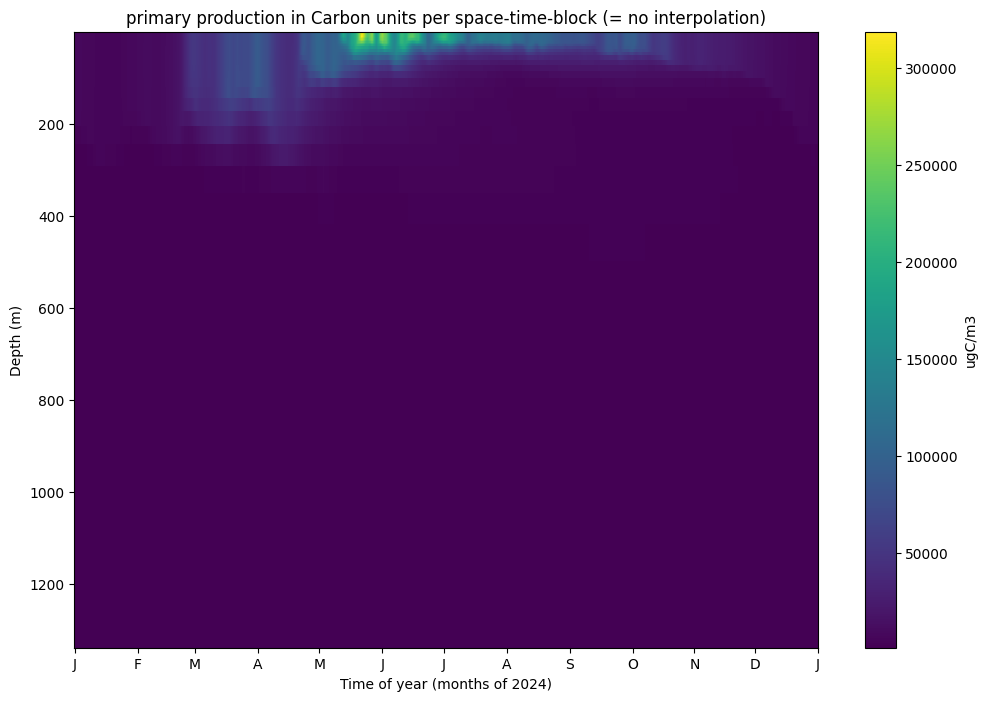

In [5]:
import matplotlib.pyplot as plt

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

# Create the plot using pcolormesh
plt.figure(figsize=(12, 8))

# Create the edges for pcolormesh.  We need one more depth value
# than we have data points.  A simple approach is to take the
# midpoint between the original depths.
depth_edges = np.concatenate(([depthrange[0] - (depthrange[1] - depthrange[0])/2.0],
                              (depthrange[:-1] + depthrange[1:]) / 2.0,
                              [depthrange[-1] + (depthrange[-1] - depthrange[-2])/2.0]))
time_edges = np.arange(foodconcentration_raw.shape[1] + 1) - 0.5

# Use pcolormesh
mesh = plt.pcolormesh(time_edges, depth_edges, foodconcentration_raw, cmap='viridis')
plt.colorbar(label='ugC/m3')
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months of 2024)")
plt.ylabel("Depth (m)")
plt.title("primary production in Carbon units per space-time-block (= no interpolation)")
plt.ylim(depth_edges.max(), depth_edges.min())  # Ensure depths are plotted correctly (decreasing upwards)

##### Plotting model environment :: Temperature

(1337.5, 0.5)

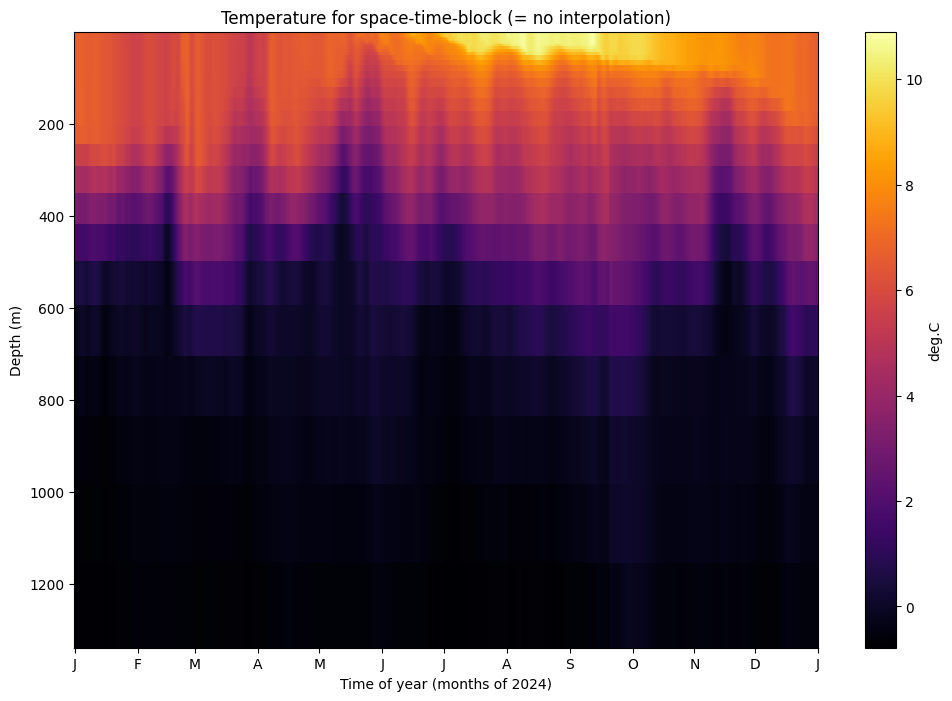

In [4]:
# Create the plot using pcolormesh
plt.figure(figsize=(12, 8))

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

# Create the edges for pcolormesh.  We need one more depth value
# than we have data points.  A simple approach is to take the
# midpoint between the original depths.
depth_edges = np.concatenate(([depthrange[0] - (depthrange[1] - depthrange[0])/2.0],
                              (depthrange[:-1] + depthrange[1:]) / 2.0,
                              [depthrange[-1] + (depthrange[-1] - depthrange[-2])/2.0]))
time_edges = np.arange(temperature.shape[1] + 1) - 0.5

# Use pcolormesh
mesh = plt.pcolormesh(time_edges, depth_edges, temperature, cmap='inferno')
plt.colorbar(label='deg.C')
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months of 2024)")
plt.ylabel("Depth (m)")
plt.title("Temperature for space-time-block (= no interpolation)")
plt.ylim(depth_edges.max(), depth_edges.min())  # Ensure depths are plotted correctly (decreasing upwards)

(1337.5, 0.5)

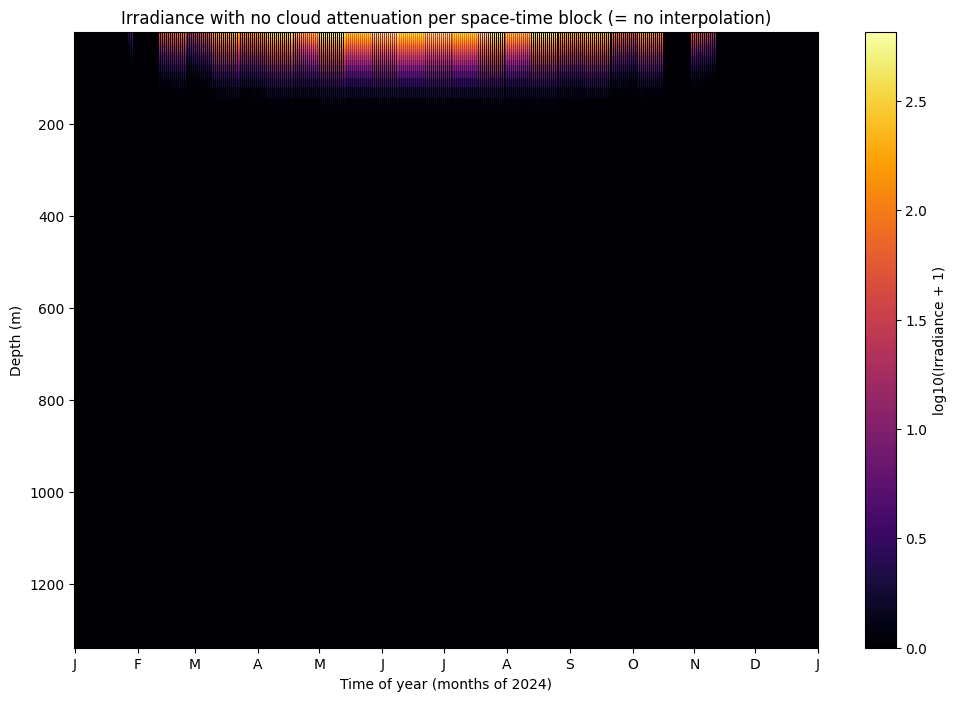

In [7]:
# Create the plot using pcolormesh
plt.figure(figsize=(12, 8))

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

irradiance_lg = np.log10(irradiance + 1)

# Create the edges for pcolormesh.  We need one more depth value
# than we have data points.  A simple approach is to take the
# midpoint between the original depths.
depth_edges = np.concatenate(([depthrange[0] - (depthrange[1] - depthrange[0])/2.0],
                              (depthrange[:-1] + depthrange[1:]) / 2.0,
                              [depthrange[-1] + (depthrange[-1] - depthrange[-2])/2.0]))
time_edges = np.arange(irradiance_lg.shape[1] + 1) - 0.5

# Use pcolormesh
mesh = plt.pcolormesh(time_edges, depth_edges, irradiance_lg, cmap='inferno')
plt.colorbar(label='log10(Irradiance + 1)')
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months of 2024)")
plt.ylabel("Depth (m)")
plt.title("Irradiance with no cloud attenuation per space-time block (= no interpolation)")
plt.ylim(depth_edges.max(), depth_edges.min())  # Ensure depths are plotted correctly (decreasing upwards)

(1337.5, 0.5)

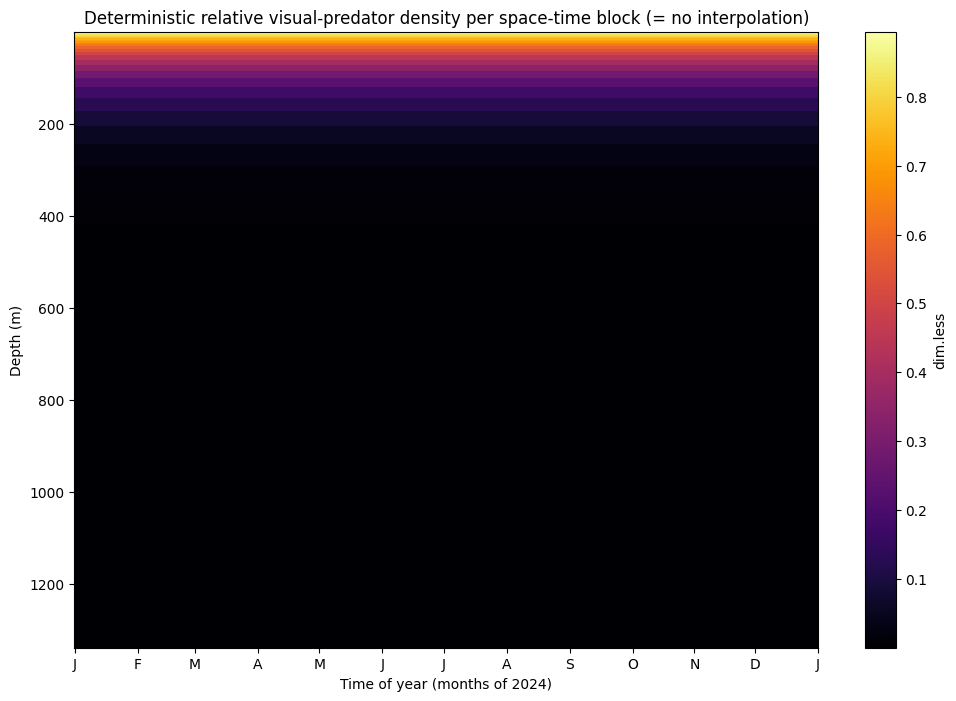

In [8]:
#NB:THIS IS ONE OF MANY POSSIBLE SPACE-TIME CONFIGURATIONS 
# Create the plot using pcolormesh
plt.figure(figsize=(12, 8))

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

# Create the edges for pcolormesh.  We need one more depth value
# than we have data points.  A simple approach is to take the
# midpoint between the original depths.
depth_edges = np.concatenate(([depthrange[0] - (depthrange[1] - depthrange[0])/2.0],
                              (depthrange[:-1] + depthrange[1:]) / 2.0,
                              [depthrange[-1] + (depthrange[-1] - depthrange[-2])/2.0]))
time_edges = np.arange(visualpredatorreldensity.shape[1] + 1) - 0.5

# Use pcolormesh
mesh = plt.pcolormesh(time_edges, depth_edges, visualpredatorreldensity, cmap='inferno')
plt.colorbar(label='dim.less')
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months of 2024)")
plt.ylabel("Depth (m)")
plt.title("Deterministic relative visual-predator density per space-time block (= no interpolation)")
plt.ylim(depth_edges.max(), depth_edges.min())  # Ensure depths are plotted correctly (decreasing upwards)

##### Importing the output HDF5 file and extracting datasets


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pathlib

datapath = pathlib.Path("/home/kanchana/Research/migratorycrossroads/outputs/testrun_8_20250522_102913")

with h5py.File(name = datapath / "PASCALv4_BITSTREAM_testrun_8_20250522_102913.h5", mode = "r") as dfile:

    print("keys in the datafile: ", list(dfile.keys()))

#end with

keys in the datafile:  ['deasummary', 'diapauseentries', 'diapauseexits', 'directdevs', 'ds_abundance', 'feedingrate', 'in_abundance', 'reservebiomass', 'somaticbiomass', 'vcexport']


In [10]:
with h5py.File(name = datapath / "PASCALv4_BITSTREAM_testrun_8_20250522_102913.h5", mode = "r") as dfile:

    print("keys in the datafile: ", list(dfile.keys()))

    abundance = dfile["ds_abundance"]
    popsize = dfile["in_abundance"]
    den = dfile["diapauseentries"]
    dex = dfile["diapauseexits"]
    ddv = dfile["directdevs"]
    vcxp = dfile["vcexport"]
    dea = dfile["deasummary"]

    abundance_np = abundance[()]
    popsize_np = popsize[()]
    den_np = den[()]
    dex_np = dex[()]
    ddv_np = ddv[()]
    vcxp_np = vcxp[()]
    dea_np = dea[()]


    # for attr_name, attr_value in abundance.attrs.items():

    #     print(f"{attr_name}: {attr_value}")

    # #end for
    
    # for attr_name, attr_value in den.attrs.items():

    #     print(f"{attr_name}: {attr_value}")

    # #end for

    # for attr_name, attr_value in dex.attrs.items():

    #     print(f"{attr_name}: {attr_value}")
        
    # #end for

    # for attr_name, attr_value in ddv.attrs.items():

    #     print(f"{attr_name}: {attr_value}")
        
    # #end for
    
    # for attr_name, attr_value in vcxp.attrs.items():

    #         print(f"{attr_name}: {attr_value}")
            
    #     #end for

    for attr_name, attr_value in dea.attrs.items():

        print(f"{attr_name}: {attr_value}")
            
    #end for

#end with

keys in the datafile:  ['deasummary', 'diapauseentries', 'diapauseexits', 'directdevs', 'ds_abundance', 'feedingrate', 'in_abundance', 'reservebiomass', 'somaticbiomass', 'vcexport']
description: datalayer: 0=mean, 1=sd | deattr: 8xattributes A0-A7
dimensions: [datalayer, time, deattr]
name: monthly means and standard deviations of dynamic evolvable attributes
units: dim.less


##### Depth-stratified abundance (vertical distribution of all stages) - raw data

In [26]:
from scipy.interpolate import interp1d

ds_abundance_int = np.repeat(0.00, 1245 * 1460).reshape(1245, 1460).astype(np.float32)
depthrange = np.array(envdataset1.variables["depth"][:]).astype(np.int32)
deptharray = np.arange(1, 1246, 1)

for i in range(1460):

    currentnumbers_raw = ds_abundance[:, i]
    intfx = interp1d(x = depthrange, y = currentnumbers_raw, kind = "linear")
    currentabundance = intfx(x = deptharray)

    ds_abundance_int[:, i] = currentabundance


#end for

In [12]:
totalabundance = np.repeat(0.00, 37 * 1460).reshape(37, 1460).astype(np.float32)

for i in range(1460):

    for j in range(depthrange.size):
    
        currentabundance = np.nansum(abundance_np[j, i, :])
        totalabundance[j, i] = currentabundance
    
    #end for

#end for

In [13]:
print(totalabundance.shape)

(37, 1460)


In [14]:
from scipy.interpolate import interp1d

ds_totalabundance_int = np.repeat(0.00, 1245 * 1460).reshape(1245, 1460).astype(np.float32)
depthrange = np.array(envdataset1.variables["depth"][:]).astype(np.int32)
deptharray = np.arange(1, 1246, 1)

for i in range(1460):

    currentnumbers_raw = totalabundance[:, i]
    intfx = interp1d(x = depthrange, y = currentnumbers_raw, kind = "linear")
    currentabundance = intfx(x = deptharray)

    ds_totalabundance_int[:, i] = currentabundance


#end for

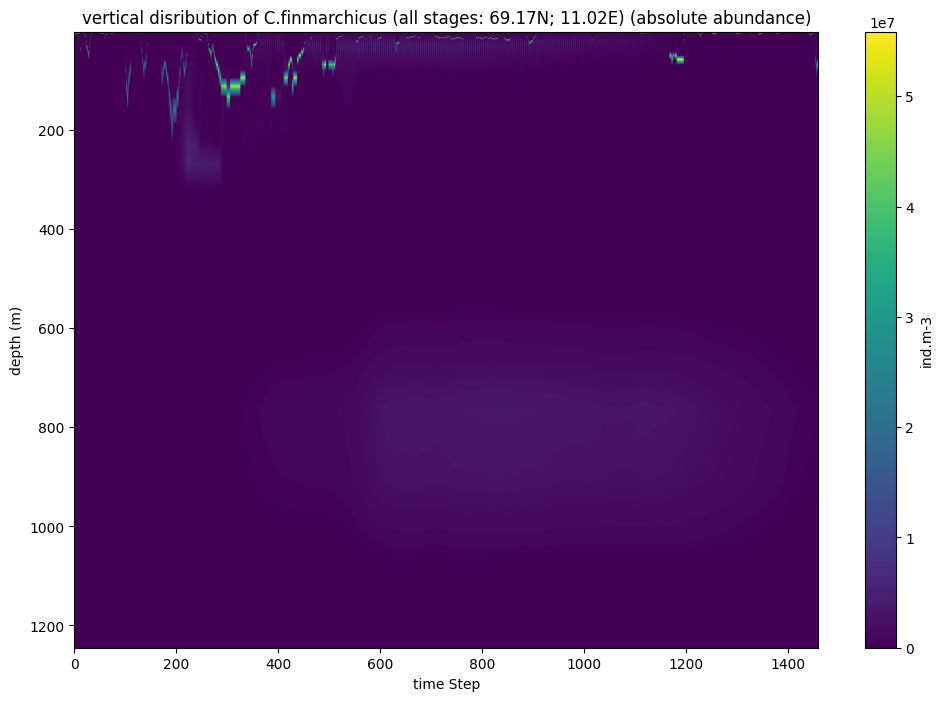

In [15]:
plt.figure(figsize=(12, 8))  # Adjust figure size for better visualization
plt.imshow(ds_totalabundance_int, aspect='auto', cmap='viridis', extent=[0, ds_totalabundance_int.shape[1], deptharray.max(), deptharray.min()])  # Use imshow for heatmap
plt.colorbar(label='ind.m-3')  # Add a colorbar for interpretation
plt.xlabel("time Step")  # Label the x-axis
plt.ylabel("depth (m)")  # Label the y-axis
plt.title("vertical disribution of C.finmarchicus (all stages: 69.17N; 11.02E) (absolute abundance)")  # Add a title
plt.show()

##### Depth-stratified abundance (vertical distribution of all stages) - transformed data

In [39]:
ds_abundance_int_trf = np.sqrt(ds_abundance_int)

/tmp/ipykernel_4911/14093808.py:1: RuntimeWarning: invalid value encountered in sqrt
  ds_abundance_int_trf = np.sqrt(ds_abundance_int)


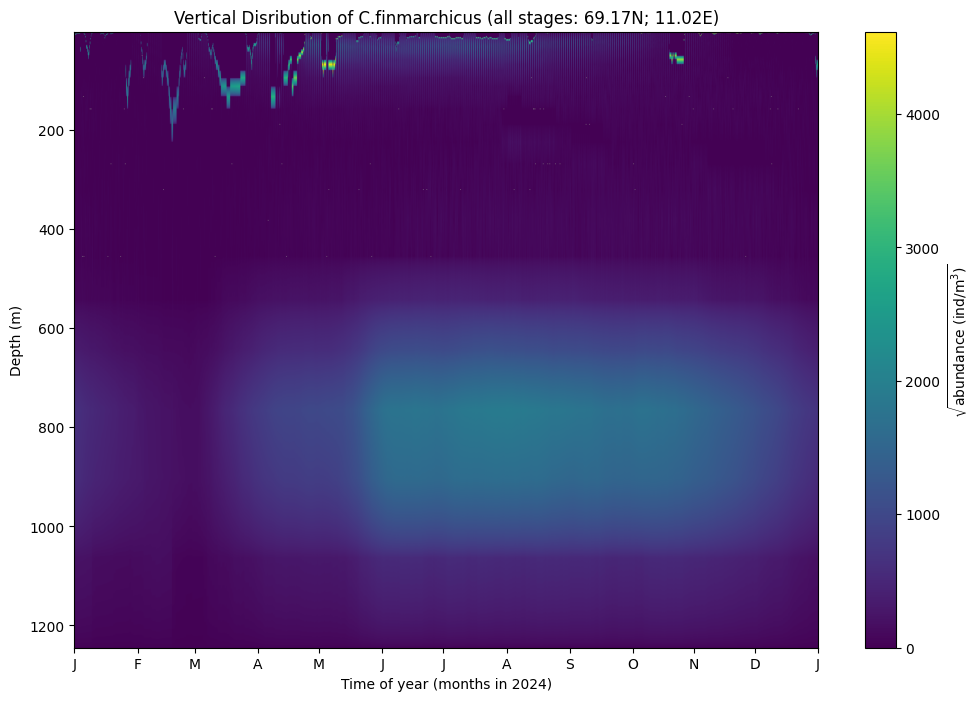

In [42]:
reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.figure(figsize=(12, 8))  # Adjust figure size for better visualization
plt.imshow(ds_abundance_int_trf, aspect='auto', cmap='viridis', extent=[0, ds_abundance_int_trf.shape[1], deptharray.max(), deptharray.min()])  # Use imshow for heatmap
plt.xticks(reportingintervals, reportinlabels)
plt.colorbar(label=r'$\sqrt{\text{abundance (ind/m}^3)}$')
plt.xlabel("Time of year (months in 2024)")  # Label the x-axis
plt.ylabel("Depth (m)")  # Label the y-axis
plt.title("Vertical Disribution of C.finmarchicus (all stages: 69.17N; 11.02E)")  # Add a title
plt.show()


##### Vertical carbon export (POC or egested carbon)

In [43]:
print(vcxp_np.shape)

poc_allstgs = np.repeat(0.00, 37 * 1460).reshape(37, 1460).astype(np.float32)

for i in range(1460):

    for j in range(37):

        current_poc = np.nansum(vcxp_np[0, j, i, :])
        poc_allstgs[j, i] = current_poc

    #end for

#end for


(2, 37, 1460, 14)


In [44]:
from scipy.interpolate import interp1d

poc_allstgs_int = np.repeat(0.00, 1245 * 1460).reshape(1245, 1460).astype(np.float32)
depthrange = np.array(envdataset1.variables["depth"][:]).astype(np.int32)
deptharray = np.arange(1, 1246, 1)

for i in range(1460):

    currentnumbers_raw = poc_allstgs[:, i]
    intfx = interp1d(x = depthrange, y = currentnumbers_raw, kind = "linear")
    currentabundance = intfx(x = deptharray)

    poc_allstgs_int[:, i] = currentabundance


#end for

/tmp/ipykernel_4911/1680397784.py:1: RuntimeWarning: invalid value encountered in sqrt
  poc_allstgs_int_trf = np.sqrt(poc_allstgs_int)


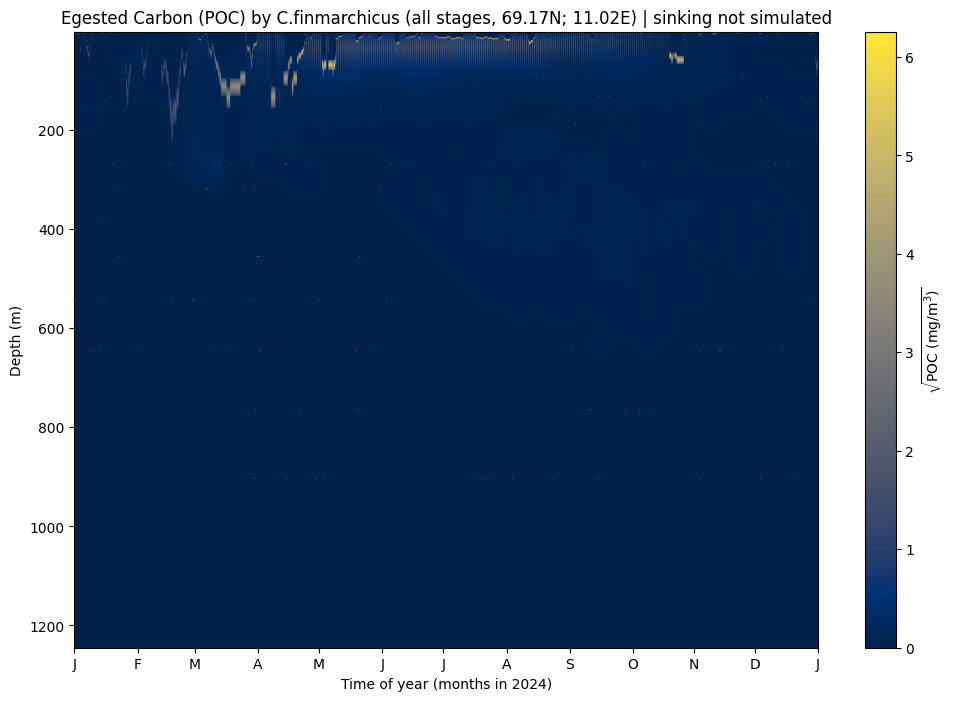

In [50]:
poc_allstgs_int_trf = np.sqrt(poc_allstgs_int)

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.figure(figsize=(12, 8))  # Adjust figure size for better visualization
plt.imshow(poc_allstgs_int_trf, aspect='auto', cmap='cividis', extent=[0, poc_allstgs_int_trf.shape[1], deptharray.max(), deptharray.min()])  # Use imshow for heatmap
plt.xticks(reportingintervals, reportinlabels)
plt.colorbar(label=r'$\sqrt{\text{POC (mg/m}^3)}$')
plt.xlabel("Time of year (months in 2024)")  # Label the x-axis
plt.ylabel("Depth (m)")  # Label the y-axis
plt.title("Egested Carbon (POC) by C.finmarchicus (all stages, 69.17N; 11.02E) | sinking not simulated")  # Add a title
plt.show()

##### Vertical carbon export (DIC/respired carbon)

In [51]:
print(vcxp_np.shape)

dic_allstgs = np.repeat(0.00, 37 * 1460).reshape(37, 1460).astype(np.float32)

for i in range(1460):

    for j in range(37):

        current_dic = np.nansum(vcxp_np[1, j, i, :])
        dic_allstgs[j, i] = current_dic

    #end for

#end for

(2, 37, 1460, 14)


In [52]:
from scipy.interpolate import interp1d

dic_allstgs_int = np.repeat(0.00, 1245 * 1460).reshape(1245, 1460).astype(np.float32)
depthrange = np.array(envdataset1.variables["depth"][:]).astype(np.int32)
deptharray = np.arange(1, 1246, 1)

for i in range(1460):

    currentnumbers_raw = dic_allstgs[:, i]
    intfx = interp1d(x = depthrange, y = currentnumbers_raw, kind = "linear")
    currentabundance = intfx(x = deptharray)

    dic_allstgs_int[:, i] = currentabundance


#end for

/tmp/ipykernel_4911/3544355775.py:1: RuntimeWarning: invalid value encountered in sqrt
  dic_allstgs_int_trf = np.sqrt(dic_allstgs_int)


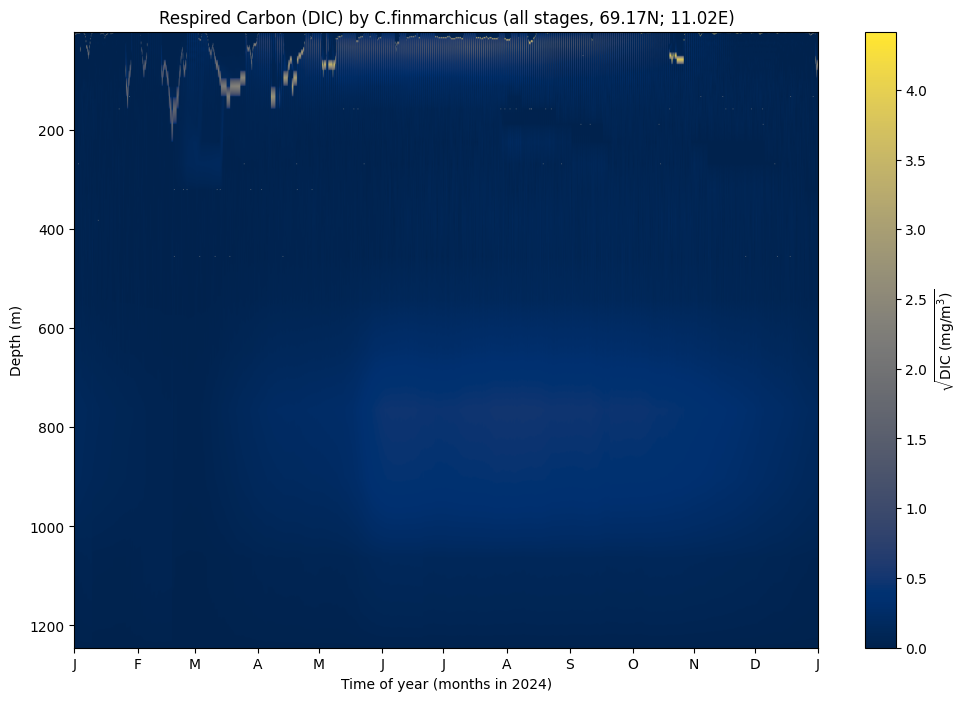

In [53]:
dic_allstgs_int_trf = np.sqrt(dic_allstgs_int)

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.figure(figsize=(12, 8))  # Adjust figure size for better visualization
plt.imshow(dic_allstgs_int_trf, aspect='auto', cmap='cividis', extent=[0, dic_allstgs_int_trf.shape[1], deptharray.max(), deptharray.min()])  # Use imshow for heatmap
plt.xticks(reportingintervals, reportinlabels)
plt.colorbar(label=r'$\sqrt{\text{DIC (mg/m}^3)}$')
plt.xlabel("Time of year (months in 2024)")  # Label the x-axis
plt.ylabel("Depth (m)")  # Label the y-axis
plt.title("Respired Carbon (DIC) by C.finmarchicus (all stages, 69.17N; 11.02E)")  # Add a title
plt.show()

##### Life-history strategies

(3, 1460, 2, 2)


Text(0.5, 1.0, 'Diapause entries (69.17N; 11.02E)')

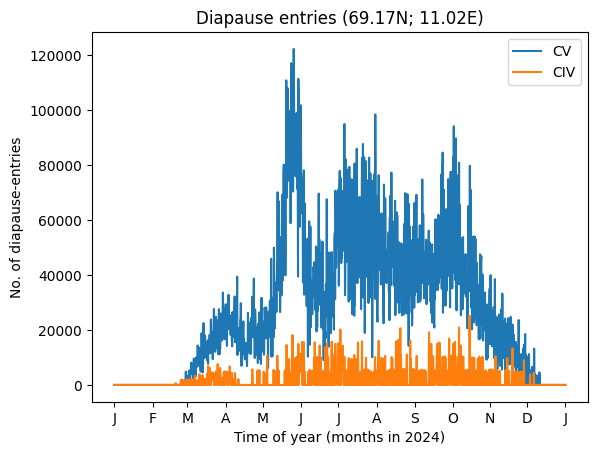

In [60]:
print(den_np.shape)
reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.plot(den_np[0, :, 1, 0])
plt.plot(den_np[0, :, 0, 0])
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months in 2024)")
plt.ylabel("No. of diapause-entries")
plt.legend(["CV", "CIV"])
plt.title("Diapause entries (69.17N; 11.02E)")

(3, 1460, 2, 2)


Text(0.5, 1.0, 'Diapause exits (69.17N; 11.02E)')

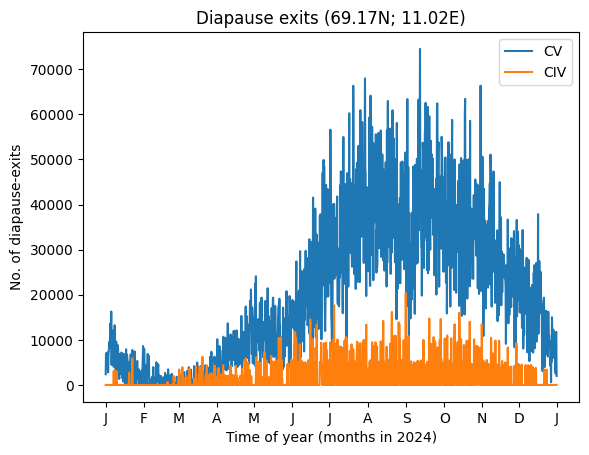

In [59]:
print(dex_np.shape)
reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.plot(dex_np[0, :, 1, 0])
plt.plot(dex_np[0, :, 0, 0])
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months in 2024)")
plt.ylabel("No. of diapause-exits")
plt.legend(["CV", "CIV"])
plt.title("Diapause exits (69.17N; 11.02E)")

(3, 1460, 2)


Text(0.5, 1.0, "Dynamic evolvable attributes ('genes') in the population")

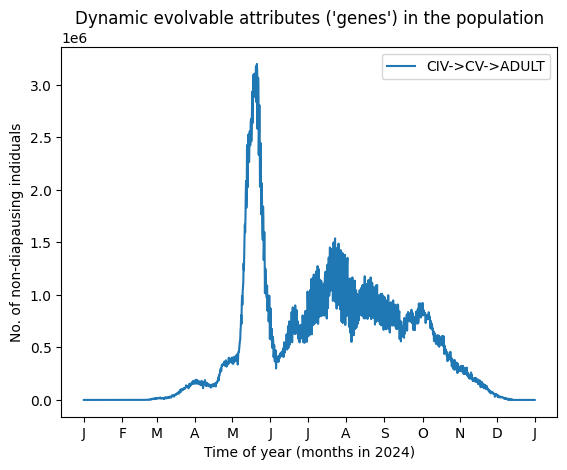

In [58]:
print(ddv_np.shape)

reportingintervals = np.array([0, 124, 236, 360, 480, 604, 724, 848, 972, 1096, 1216, 1336, 1459]).astype(np.int32)
reportinlabels = np.array(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D", "J"]).astype("U1")

plt.plot(ddv_np[0, :, 0])
plt.xticks(reportingintervals, reportinlabels)
plt.xlabel("Time of year (months in 2024)")
plt.ylabel("No. of non-diapausing indiduals")
plt.legend(["CIV->CV->ADULT"])
plt.title("Dynamic evolvable attributes ('genes') in the population")

##### Simulated evolution of the population (SR)

(2, 612, 8)


Text(0.5, 1.0, "Dynamic evolvable attributes ('genes') in the population")

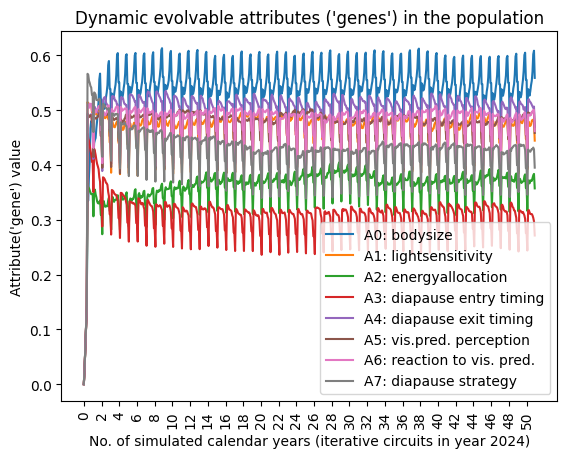

In [120]:
print(dea_np.shape)

plt.plot(dea_np[0, :, :])
plt.xticks(np.arange(0, 612, 24), rotation = 90, labels = np.arange(0, 52, 2))
plt.xlabel("No. of simulated calendar years (iterative circuits in year 2024)")
plt.ylabel("Attribute('gene') value")
plt.legend(["A0: bodysize", "A1: lightsensitivity", "A2: energyallocation", "A3: diapause entry timing", "A4: diapause exit timing", "A5: vis.pred. perception", "A6: reaction to vis. pred.", "A7: diapause strategy"])
plt.title("Dynamic evolvable attributes ('genes') in the population")